## Import Libraries and Datasets

In [28]:
# --- import libreries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [29]:
# --- import and view dataset --- 
df = pd.read_csv('/kaggle/input/datasets/jainilcoder/online-payment-fraud-detection/onlinefraud.csv')
display(df.head())
print('\n==========================================================================================================')
print(df.info())
print('\n==========================================================================================================')
print(df.isnull().sum())
print('\n==========================================================================================================')
print(df.duplicated().sum())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

0


## Let's Explore

In [30]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

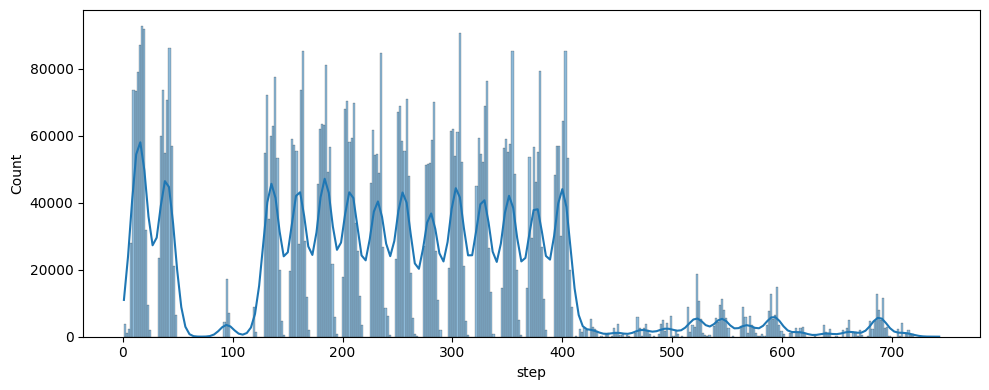

In [31]:
plt.figure(figsize = (10, 4))
sns.histplot(x = df['step'], kde = True)
plt.tight_layout()
plt.show()

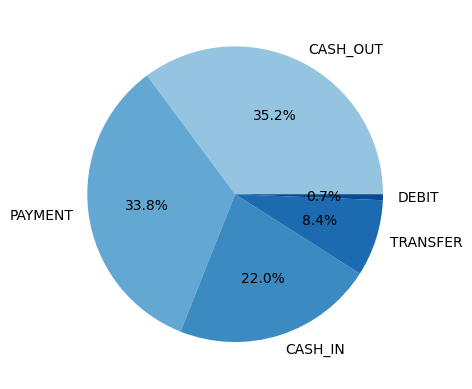

In [32]:
counts = df['type'].value_counts()
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(counts)))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=colors
)
plt.show()

In [33]:
print(df['nameDest'].duplicated().sum())
print(df['nameOrig'].duplicated().sum())

3640258
9313


In [34]:
print((df['isFraud'] == df['isFlaggedFraud']).sum() / df.shape[0])

0.9987116942391656


Almost all the flagged results are correct 

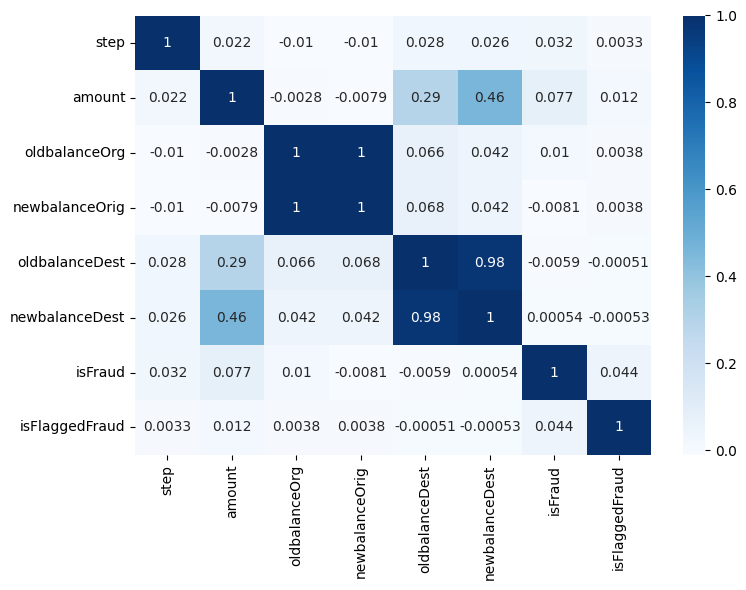

In [35]:
plt.figure(figsize = (8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot = True, 
    cmap='Blues'
)
plt.tight_layout()
plt.show()

Let's choose our features based on which we are going to make the model. 

In [36]:
df = df.drop(columns = ['step', 'nameOrig', 'nameDest', 'isFlaggedFraud'])

## Split and Feature Scaling  

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

y = df['isFraud']
X = df.drop(columns = ['isFraud'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_cols),
        ('num',StandardScaler(),numeric_cols)])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Test and Validate

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()}

In [40]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    # Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training Naive Bayes...


In [41]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)
print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Decision Tree  0.999751   0.907248  0.898965  0.903088  0.949423
2        Random Forest  0.999687   0.960089  0.790627  0.867156  0.992860
3                  KNN  0.999607   0.933941  0.748631  0.831081  0.923154
0  Logistic Regression  0.999121   0.967914  0.330493  0.492740  0.965191
4          Naive Bayes  0.566156   0.002967  1.000000  0.005917  0.911256


In [42]:
best_model_name = results_df.iloc[0]['Model']

print("\nBest Model based on F1 Score:")
print(best_model_name)


Best Model based on F1 Score:
Decision Tree
